In [3]:
import requests
import pandas as pd

#Dodałem parametr ?fields= na końcu adresu URL
url = "https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,currencies"
print("Pobieram dane z API, to może chwilę potrwać...")

response = requests.get(url, timeout=15)

if response.status_code != 200:
    print(f"Błąd API! Serwer zwrócił kod: {response.status_code}")
    print(f"Treść odpowiedzi: {response.text}")
else:
    data = response.json()
    
    if isinstance(data, list):
        processed_data = []

        for country in data:
            nazwa = country.get('name', {}).get('common', 'N/A')
            
            stolica_list = country.get('capital', [])
            stolica = stolica_list[0] if stolica_list else 'Brak'
            
            region = country.get('region', 'N/A')
            subregion = country.get('subregion', 'N/A')
            
            populacja = country.get('population', 0)
            powierzchnia = country.get('area', 0.0)
            
            waluty_dict = country.get('currencies', {})
            waluta = list(waluty_dict.keys())[0] if waluty_dict else 'Brak'
            
            processed_data.append({
                "nazwa": nazwa,
                "stolica": stolica,
                "region": region,
                "subregion": subregion,
                "populacja": populacja,
                "powierzchnia": powierzchnia,
                "waluta": waluta
            })

        df = pd.DataFrame(processed_data)

        print("--- INFORMACJE O DATAFRAME ---")
        print(f"Kształt (wiersze, kolumny): {df.shape}")
        print("\n--- TYPY DANYCH ---")
        print(df.dtypes)
        print("\n--- PIĘĆ PIERWSZYCH WIERSZY ---")
        display(df.head()) 
    else:
        print("Błąd struktury: API nie zwróciło listy krajów. Zwróciło:", type(data))

Pobieram dane z API, to może chwilę potrwać...
--- INFORMACJE O DATAFRAME ---
Kształt (wiersze, kolumny): (250, 7)

--- TYPY DANYCH ---
nazwa               str
stolica             str
region              str
subregion           str
populacja         int64
powierzchnia    float64
waluta              str
dtype: object

--- PIĘĆ PIERWSZYCH WIERSZY ---


,nazwa,stolica,region,subregion,populacja,powierzchnia,waluta
0,Denmark,Copenhagen,Europe,Northern Europe,6011488,43094.0,DKK
1,Sri Lanka,Sri Jayawardenepura Kotte,Asia,Southern Asia,21763170,65610.0,LKR
2,Montserrat,Plymouth,Americas,Caribbean,4386,102.0,XCD
3,South Africa,Pretoria,Africa,Southern Africa,63100945,1221037.0,ZAR
4,Bahrain,Manama,Asia,Western Asia,1594654,765.0,BHD


In [4]:
import sqlite3

db_name = "kraje_swiata.db"
conn = sqlite3.connect(db_name)

df.to_sql('kraje', conn, if_exists='replace', index=False)

conn.close()

print(f"Sukces! Dane zostały zapisane do bazy '{db_name}' w tabeli 'kraje'.")

import os
print(f"Pliki w folderze projektu: {os.listdir('.')}")

Sukces! Dane zostały zapisane do bazy 'kraje_swiata.db' w tabeli 'kraje'.
Pliki w folderze projektu: ['uv.lock', 'Zadanie1.ipynb', 'pyproject.toml', 'README.md', 'kraje_swiata.db', '.gitignore', '.venv', '.python-version', '.git', 'main.py']


In [5]:
import sqlite3
import pandas as pd

#Połączenie z bazą
conn = sqlite3.connect("kraje_swiata.db")

print("--- 1. Łączna populacja świata ---")
query1 = "SELECT SUM(populacja) AS laczna_populacja_swiata FROM kraje"
df_total_pop = pd.read_sql_query(query1, conn)
display(df_total_pop)

print("\n--- 2. Top 10 krajów z największą populacją ---")
query2 = """
    SELECT nazwa, populacja 
    FROM kraje 
    ORDER BY populacja DESC 
    LIMIT 10
"""
df_top_pop = pd.read_sql_query(query2, conn)
display(df_top_pop)

print("\n--- 3. Liczba krajów i średnia populacja w regionach ---")
query3 = """
    SELECT region, 
           COUNT(*) AS liczba_krajow, 
           ROUND(AVG(populacja), 2) AS srednia_populacja 
    FROM kraje 
    GROUP BY region
    ORDER BY liczba_krajow DESC
"""
df_regions = pd.read_sql_query(query3, conn)
display(df_regions)

print("\n--- 4. Kraje większe od Polski (~312 679 km²) ---")

query4 = """
    SELECT nazwa, powierzchnia 
    FROM kraje 
    WHERE powierzchnia > 312679 
    ORDER BY powierzchnia ASC
"""
df_larger_than_pl = pd.read_sql_query(query4, conn)
print(f"Liczba krajów większych od Polski: {len(df_larger_than_pl)}")
display(df_larger_than_pl.head(10)) # Wyświetlamy 10 najmniejszych z tych większych od PL

print("\n--- 5. Kraj z najwyższą gęstością zaludnienia ---")
# Gęstość = populacja / powierzchnia. 
# Omijamy kraje z powierzchnią 0, żeby nie dzielić przez zero.
query5 = """
    SELECT nazwa, 
           populacja, 
           powierzchnia, 
           (populacja / powierzchnia) AS gestosc_zaludnienia
    FROM kraje 
    WHERE powierzchnia > 0
    ORDER BY gestosc_zaludnienia DESC 
    LIMIT 1
"""
df_density = pd.read_sql_query(query5, conn)
display(df_density)


conn.close()

--- 1. Łączna populacja świata ---


,laczna_populacja_swiata
0,8019495460



--- 2. Top 10 krajów z największą populacją ---


,nazwa,populacja
0,India,1417492000
1,China,1408280000
2,United States,340110988
3,Indonesia,284438782
4,Pakistan,241499431
5,Nigeria,223800000
6,Brazil,213421037
7,Bangladesh,169828911
8,Russia,146028325
9,Mexico,130575786



--- 3. Liczba krajów i średnia populacja w regionach ---


,region,liczba_krajow,srednia_populacja
0,Africa,59,24787532.39
1,Americas,56,18617496.13
2,Europe,53,13993545.70
3,Asia,50,94494639.32
4,Oceania,27,1779988.07
5,Antarctic,5,340.00



--- 4. Kraje większe od Polski (~312 679 km²) ---
Liczba krajów większych od Polski: 71


,nazwa,powierzchnia
0,Ivory Coast,322463.0
1,Malaysia,330803.0
2,Vietnam,331212.0
3,Finland,338455.0
4,Republic of the Congo,342000.0
5,Philippines,342353.0
6,Germany,357114.0
7,Japan,377930.0
8,Norway,386224.0
9,Zimbabwe,390757.0



--- 5. Kraj z najwyższą gęstością zaludnienia ---


,nazwa,populacja,powierzchnia,gestosc_zaludnienia
0,Macau,685900,30.0,22863.333333


Matplotlib is building the font cache; this may take a moment.


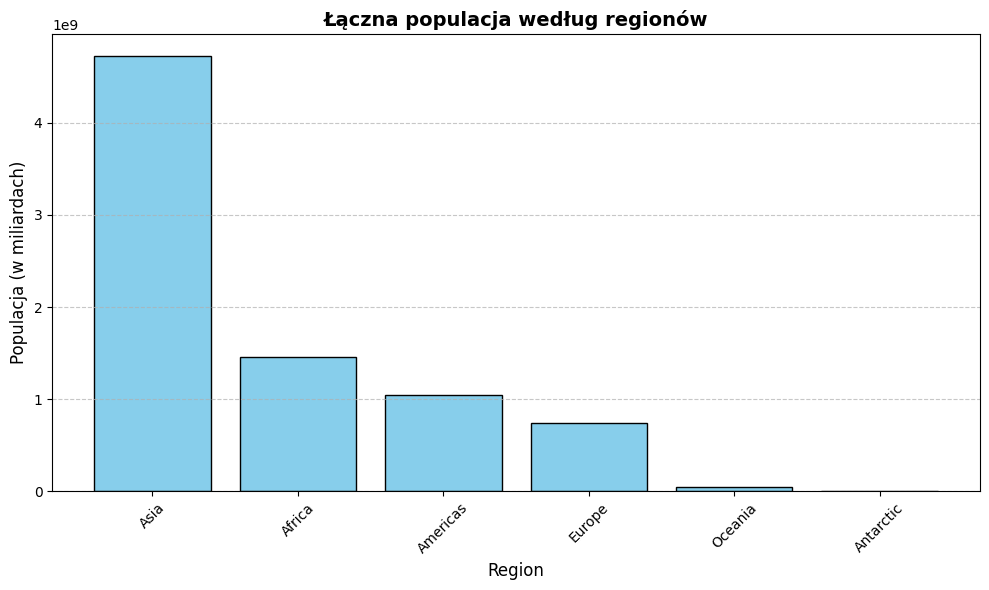

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Robranie potrzebnych danych z bazy
conn = sqlite3.connect("kraje_swiata.db")

query_wykres = """
    SELECT region, SUM(populacja) AS laczna_populacja 
    FROM kraje 
    GROUP BY region
    ORDER BY laczna_populacja DESC
"""
df_wykres = pd.read_sql_query(query_wykres, conn)
conn.close()

# Rysowanie wykresu słupkowego
plt.figure(figsize=(10, 6)) # Ustawienie rozmiaru wykresu

# Rysowanie słupków: oś X to region, oś Y to łączna populacja
plt.bar(df_wykres['region'], df_wykres['laczna_populacja'], color='skyblue', edgecolor='black')


plt.title('Łączna populacja według regionów', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Populacja (w miliardach)', fontsize=12)
plt.xticks(rotation=45) # Obrócenie podpisów osi X, żeby na siebie nie nachodziły
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Automatyczne dopasowanie marginesów
plt.show() 